# The check
### Rebuilding the snow poster from the raw DWD files

I drew a poster from 75 years of DWD snow grids. Before publishing it I wanted one thing settled:
that the files the site ships are exactly what the raw data gives, with no project code in between.
This notebook is that check. It reads DWD's own files from `raw/`, rebuilds the two period grids,
recounts the headline numbers and compares everything with what is published.

It also works through the four things a careful reader asks about: cells with more than 365 days,
one weather station counted by hand, where the series splits, and what smoothing and sampling cost.

## Results at a glance

| Check | Result |
|---|---|
| Period grids rebuilt from raw | identical to the shipped files, 0 difference across 47,415 values each |
| Country average, 1961 to 1990 and 1991 to 2020 | 47.52 and 31.54 days a year, match |
| Split in the series | after 1987, 48.3 days a year before and 29.2 after, match |
| Berlin-Dahlem, counted by hand | 43.4 and 29.5 days a year, match; the grid cell reads 0.9 and 2.8 days lower |
| Cells above 365 days | 4 cells, 12 cell-years; capping them moves an average by five millionths of a day at most |
| Cost of sampling | median 0.86 days per kept sample, 90th percentile 4.3, worst 36 on an Alpine slope |

> **Why no project code?** If this notebook imported `scripts/prepare.py`, it would only prove that
> the script agrees with itself. Every function here is written again from the DWD file format, so
> an agreement means two independent readings of the raw files land on the same bytes.

---

*Full check below. Run `bash scripts/download.sh` first; the notebook takes about a minute.*

### Setup

Imports, paths, and the poster's colours so the charts here match the site.

In [1]:
import gzip, glob, zipfile, csv, io, json, collections
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = ROOT / "raw" / "grids"
YEARS = list(range(1951, 2026))

def load(year):
    """One raw year, straight from the gzip. Returns days and the file header."""
    with gzip.open(RAW / f"snow_{year}.asc.gz", "rt") as f:
        head = {}
        for _ in range(6):
            key, value = f.readline().split()
            head[key.upper()] = float(value)
        grid = np.loadtxt(f)
    grid[grid == head["NODATA_VALUE"]] = np.nan   # -999 means outside Germany
    return grid, head

# the poster's colours, so the two charts here match the site
COLORS = {"paper": "#f7f3ec", "ink": "#21201c", "muted": "#6f675c", "accent": "#b5432e"}
plt.rcParams["figure.facecolor"] = COLORS["paper"]
plt.rcParams["axes.facecolor"] = COLORS["paper"]
plt.rcParams["text.color"] = COLORS["ink"]
plt.rcParams["axes.labelcolor"] = COLORS["muted"]
plt.rcParams["xtick.color"] = COLORS["muted"]
plt.rcParams["ytick.color"] = COLORS["muted"]

print(f"{len(list(RAW.glob('snow_*.asc.gz')))} raw files found in {RAW}")

75 raw files found in /Users/chirag/Documents/snow-lines/raw/grids


## Step 1: One raw file

DWD publishes one file per calendar year: six header lines, then 866 rows of 654 numbers. Each
number is one square kilometre and counts the mornings that year with at least 1 cm of snow on the
ground. 1970 first.

In [2]:
grid, head = load(1970)

for key, value in head.items():
    print(f"{key:14s} {value:,.0f}" if value == int(value) else f"{key:14s} {value:,.4f}")

print()
print(f"shape        {grid.shape[0]} rows x {grid.shape[1]} columns")
print(f"cells        {grid.size:,}")
print(f"one cell     {head['CELLSIZE']:.0f} m x {head['CELLSIZE']:.0f} m")

NCOLS          654
NROWS          866
XLLCORNER      3,280,414.7116
YLLCORNER      5,237,500.6289
CELLSIZE       1,000
NODATA_VALUE   -999

shape        866 rows x 654 columns
cells        566,364
one cell     1000 m x 1000 m


The value -999 marks "not Germany": the sea and everything over the border. It is not a zero, and
treating it as one is the easiest mistake in this dataset.

In [3]:
land = ~np.isnan(grid)
print(f"inside Germany   {land.sum():,} cells")
print(f"outside          {(~land).sum():,} cells")
print()
print(f"average over land          {np.nanmean(grid):6.2f} days")
print(f"average if -999 were zero  {np.nan_to_num(grid).mean():6.2f} days   <- wrong by a third")

inside Germany   358,303 cells
outside          208,061 cells

average over land           84.43 days
average if -999 were zero   53.41 days   <- wrong by a third


Wrong by a third. An early version of one figure in this project counted the sea as land with no
snow. Every count here divides by land cells only. Here is that mask, with no coordinates involved.

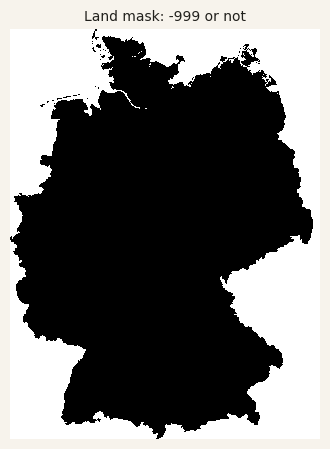

In [4]:
plt.figure(figsize=(4, 5.4))
plt.imshow(land, cmap="Greys", interpolation="nearest")
plt.title("Land mask: -999 or not", fontsize=10)
plt.axis("off")
plt.show()

## Step 2: Cells above 365 days

A year has 365 days. A few cells carry more, which is possible because a cell is a modelled estimate
for a square kilometre, not a count. This cell reads all 75 years, so it takes a few seconds.

In [5]:
grids = {year: load(year)[0] for year in YEARS}

over = []
for year, g in grids.items():
    for r, c in zip(*np.where(g > 365)):
        over.append({"year": year, "row": int(r), "col": int(c), "days": float(g[r, c])})

land_cell_years = sum(int(np.sum(~np.isnan(g))) for g in grids.values())
print(f"{len(over)} cell-years above 365, out of {land_cell_years:,} inside Germany")
print(f"years:  {sorted({o['year'] for o in over})}")
print(f"highest: {max(o['days'] for o in over):.0f} days")
print()
per_cell = collections.Counter((o["row"], o["col"]) for o in over)
for (r, c), n in per_cell.most_common():
    print(f"  row {r}, col {c}:  {n} year(s)")

12 cell-years above 365, out of 26,872,725 inside Germany
years:  [1962, 1970, 1973, 1974, 1980, 1981]
highest: 375 days

  row 862, col 317:  6 year(s)
  row 828, col 514:  3 year(s)
  row 860, col 321:  2 year(s)
  row 832, col 512:  1 year(s)


Four cells in two places: the Allgau Alps at Germany's southern tip and the Berchtesgaden Alps. Both
are the highest ground in their corner of the country, where DWD's height regression reaches
furthest from its nearest station. I left them as published. The question is whether they matter.

In [6]:
def country_mean(g):
    return np.nanmean(g)

published = np.array([country_mean(grids[y]) for y in YEARS])
clipped = np.array([country_mean(np.clip(grids[y], 0, 365)) for y in YEARS])
Y = np.array(YEARS)

print(f"{'period':<12}{'published':>12}{'clipped to 365':>16}{'difference':>14}")
for a, b in ((1961, 1990), (1991, 2020)):
    m = (Y >= a) & (Y <= b)
    p, c = published[m].mean(), clipped[m].mean()
    print(f"{a}-{b:<7}{p:12.6f}{c:16.6f}{abs(p - c):14.8f}")

period         published  clipped to 365    difference
1961-1990      47.515688       47.515684    0.00000474
1991-2020      31.543494       31.543494    0.00000000


They do not. Capping them at 365 moves the 1961 to 1990 average by five millionths of a day and
the 1991 to 2020 average by nothing.
Nothing on the poster is above 365, and `scripts/verify.mjs` checks that before every build.

## Step 3: One station, counted by hand

The grid is worked out from stations. The fair test is to take a station's own daily readings, count
the snow days directly, and compare with the grid at that spot.

Berlin-Dahlem, station 403. The column `SHK_TAG` is the snow depth in centimetres at the morning
reading. A snow day is one where it is 1 or more.

In [7]:
station_zip = glob.glob(str(ROOT / "raw" / "stations" / "tageswerte_KL_00403_*.zip"))[0]
z = zipfile.ZipFile(station_zip)
member = [n for n in z.namelist() if n.startswith("produkt_klima_tag")][0]

snow_days, readings = collections.Counter(), collections.Counter()
for row in csv.DictReader(io.TextIOWrapper(z.open(member), encoding="latin-1"), delimiter=";"):
    row = {k.strip(): v.strip() for k, v in row.items()}
    year, depth = int(row["MESS_DATUM"][:4]), row["SHK_TAG"]
    if depth in ("", "-999"):      # missing reading, not a day without snow
        continue
    readings[year] += 1
    snow_days[year] += float(depth) >= 1

print(f"{'year':<8}{'readings':>10}{'snow days':>12}")
for year in (1970, 1987, 2000, 2010, 2024):
    print(f"{year:<8}{readings[year]:>10}{snow_days[year]:>12}")

year      readings   snow days
1970           365          97
1987           365          67
2000           366          14
2010           365          93
2024           366           7


A year counts only if the station has at least 330 readings, so a gap is never mistaken for a
winter without snow. Averaged over each period, and compared with what the site ships:

In [8]:
gauge = {}
for name, (a, b) in {"1961-1990": (1961, 1990), "1991-2020": (1991, 2020)}.items():
    full = [y for y in range(a, b + 1) if readings[y] >= 330]
    gauge[name] = sum(snow_days[y] for y in full) / len(full)
    print(f"{name}: {gauge[name]:.1f} days a year, from {len(full)} complete years")

shipped_gauge = json.load(open(ROOT / "src/data/gauges.json"))["403"]
print()
print("what src/data/gauges.json ships:",
      {k: v["mean"] for k, v in shipped_gauge["periods"].items()})

1961-1990: 43.4 days a year, from 30 complete years
1991-2020: 29.5 days a year, from 30 complete years

what src/data/gauges.json ships: {'1961-1990': 43.4, '1991-2020': 29.5}


Now the grid cell at that spot over the same years, read straight from the raw files.

In [9]:
r, c = shipped_gauge["grid"]["row"], shipped_gauge["grid"]["col"]
print(f"Berlin-Dahlem sits in row {r}, column {c}")
print()
print(f"{'period':<12}{'station by hand':>18}{'raw grid cell':>16}{'gap':>8}")
for name, (a, b) in {"1961-1990": (1961, 1990), "1991-2020": (1991, 2020)}.items():
    full = [y for y in range(a, b + 1) if readings[y] >= 330]
    cell = np.mean([grids[y][r, c] for y in full])
    print(f"{name:<12}{gauge[name]:18.1f}{cell:16.1f}{abs(gauge[name] - cell):8.1f}")

Berlin-Dahlem sits in row 281, column 512

period         station by hand   raw grid cell     gap
1961-1990                 43.4            42.5     0.9
1991-2020                 29.5            26.7     2.8


The grid runs just under a day below the station in the first period and just under three in the
second. A cell is an average over a square kilometre, and Dahlem is a green corner of a warm city, so
a small gap is expected. The method page shows this comparison for nine stations.

## Step 4: Every year, and the split

One number per year: the average over every land cell. This is the series the method page's chart
draws.

In [10]:
series = np.array([np.nanmean(grids[y]) for y in YEARS])

for a, b in ((1961, 1990), (1991, 2020)):
    m = (Y >= a) & (Y <= b)
    print(f"{a} to {b}: {series[m].mean():.2f} days a year")

print()
print(f"highest year  {YEARS[series.argmax()]}, {series.max():.1f} days")
print(f"lowest year   {YEARS[series.argmin()]}, {series.min():.1f} days")

1961 to 1990: 47.52 days a year
1991 to 2020: 31.54 days a year

highest year  2010, 90.6 days
lowest year   2020, 8.8 days


The method page says the fall is one drop, not a slow decline. The test: try every year as the split,
give each side its own average, and measure how much of the variation is left over. The split that
leaves the least is the best single step.

Picking the split with the biggest jump between the two averages would not work. It always lands
near the end of the series, where a few years can have an extreme average by chance. Both are below
so the difference is visible.

In [11]:
def best_step(v):
    """The split that leaves the least unexplained wiggle. Least squares, not biggest gap."""
    best = None
    for k in range(5, len(v) - 5):          # need a few years on each side
        before, after = v[:k], v[k:]
        left_over = ((before - before.mean()) ** 2).sum() + ((after - after.mean()) ** 2).sum()
        if best is None or left_over < best[0]:
            best = (left_over, k, before.mean(), after.mean())
    return best

def biggest_gap(v):
    """The tempting shortcut, kept here to show why it fails."""
    return max(range(5, len(v) - 5), key=lambda k: abs(v[k:].mean() - v[:k].mean()))

left_over, k, before, after = best_step(series)
print(f"least squares : break after {YEARS[k - 1]}, {before:.1f} days then {after:.1f}")
print(f"biggest gap   : break after {YEARS[biggest_gap(series) - 1]}   <- always near the end")

least squares : break after 1987, 48.3 days then 29.2
biggest gap   : break after 2018   <- always near the end


1987. Marty (2008) found the same in Swiss station records: a step at the end of the 1980s and no
clear trend since.

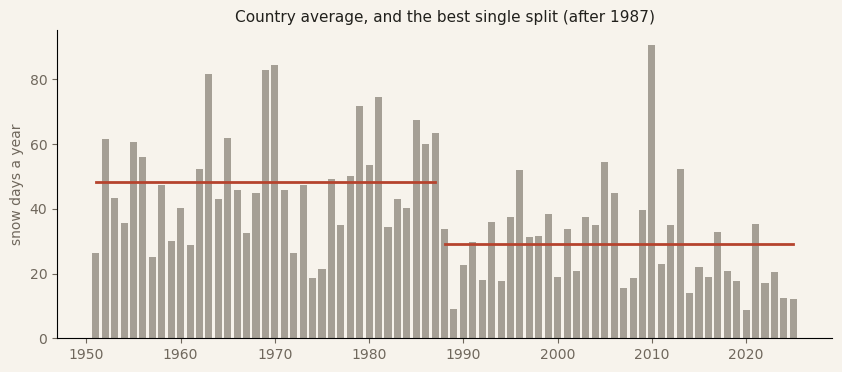

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(YEARS, series, color=COLORS["muted"], alpha=0.6, width=0.75)
ax.plot([YEARS[0], YEARS[k - 1]], [before, before], color=COLORS["accent"], lw=2)
ax.plot([YEARS[k], YEARS[-1]], [after, after], color=COLORS["accent"], lw=2)
ax.set_ylabel("snow days a year")
ax.set_title(f"Country average, and the best single split (after {YEARS[k - 1]})", fontsize=11)
for side in ("top", "right"): ax.spines[side].set_visible(False)
plt.show()

## Step 5: The smoother's edge

The chart draws a ten-year smoother over the bars. Near the end of the series there are no later
years to average with. The usual shortcut is to pad with the last value, and here that drags the
curve down, because 2025 was a thin year. The site cuts the kernel at the end instead and
renormalises what is left.

In [13]:
n = len(series)
sigma = 10 / 2.355                       # 10-year full width at half maximum, as in Marty 2008
w = np.exp(-0.5 * (np.arange(-n, n + 1) / sigma) ** 2)

truncated = np.array([np.sum(series * w[n - i:2 * n - i]) / np.sum(w[n - i:2 * n - i])
                      for i in range(n)])
padded = gaussian_filter(series, sigma, mode="nearest")

print(f"{'year':<8}{'truncated':>12}{'padded':>10}{'difference':>13}")
for i in range(n - 5, n):
    print(f"{YEARS[i]:<8}{truncated[i]:12.2f}{padded[i]:10.2f}{truncated[i] - padded[i]:13.2f}")

shipped_smooth = json.load(open(ROOT / "src/data/stats.json"))["smooth"]
print()
print(f"shipped last five: {shipped_smooth[-5:]}")
print(f"ours  last five:   {[round(float(x), 2) for x in truncated[-5:]]}")

year       truncated    padded   difference
2021           20.73     19.50         1.22
2022           19.97     18.39         1.58
2023           19.31     17.35         1.96
2024           18.72     16.38         2.35
2025           18.19     15.49         2.70

shipped last five: [20.72, 19.97, 19.31, 18.72, 18.19]
ours  last five:   [20.73, 19.97, 19.31, 18.72, 18.19]


Up to nearly three days' difference over the last five years, on a curve whose whole point is
the last five years. The site ships the cut version.

## Step 6: Smoothing and sampling

Two things happen to a grid before it is drawn.

Smoothing replaces each cell with a weighted average of its neighbours, 1.5 km north to south and
2.5 km east to west, so the lines do not carry the 1 km grain. At the coast the average is
renormalised, so a shore cell is not pulled toward the sea.

Sampling keeps every 6th row and every 2nd column. Rows become the lines on the poster: 866 / 6 =
145 lines. Columns are drawing resolution: 654 / 2 = 327 points per line.

Sampling discards 92 percent of the cells. This is what that costs.

In [14]:
def smooth(a):
    known = ~np.isnan(a)
    weight = gaussian_filter(known.astype(float), (1.5, 2.5))
    total = gaussian_filter(np.where(known, a, 0.0), (1.5, 2.5))
    return np.where(weight > 0.5, total / np.maximum(weight, 1e-6), np.nan)

# the 1961-1990 mean, which is what the left-hand map draws.
# a cell counts only if it has all thirty years, the same rule prepare.py uses
stack = np.stack([grids[y] for y in range(1961, 1991)])
have = np.sum(~np.isnan(stack), 0)
ref = np.where(have == 30, np.nansum(stack, 0) / np.maximum(have, 1), np.nan)
smoothed = smooth(ref)
sampled = smoothed[::6, ::2]
print(f"raw      {ref.shape}  ->  sampled {sampled.shape}")
print(f"discarded {100 * (1 - sampled.size / ref.size):.0f} percent of the cells")

# for every kept sample, how far is it from the average of the block it stands for?
gaps = []
for r in range(0, smoothed.shape[0] - 6, 6):
    for c in range(0, smoothed.shape[1] - 2, 2):
        block = smoothed[r:r + 6, c:c + 2]
        if np.isnan(block).any():
            continue
        gaps.append(abs(smoothed[r, c] - block.mean()))
gaps = np.array(gaps)

print()
print(f"samples compared  {len(gaps):,}")
print(f"median gap        {np.median(gaps):.2f} days")
print(f"90th percentile   {np.percentile(gaps, 90):.2f} days")
print(f"worst             {gaps.max():.1f} days")

raw      (866, 654)  ->  sampled (145, 327)
discarded 92 percent of the cells



samples compared  29,186
median gap        0.86 days
90th percentile   4.32 days
worst             36.4 days


Under a day for most cells. The worst cases are Alpine slopes, where 6 km really does change the
snow that much. Sampling is a drawing decision only: every number the pages quote is computed on
the full 1 km grid.

## Step 7: Do the shipped files match?

Rebuild the two period grids from the raw files and compare them, byte for byte, with what
`public/data/` serves to the browser.

In [15]:
meta = json.load(open(ROOT / "public/data/meta.json"))

def rebuild(a):
    """raw grid -> exactly what prepare.py should have written"""
    s = smooth(a)[::6, ::2]
    return np.where(np.isnan(s), meta["nodata"], np.rint(np.clip(s, 0, 400))).astype("<u2")

def shipped(key):
    return np.fromfile(ROOT / f"public/data/snow_{key}.bin",
                       dtype="<u2").reshape(meta["subRows"], meta["subCols"])

# the two period grids the poster draws, averaged from the raw years first
period_means = {}
for key, (a, b) in {"1961-1990": (1961, 1990), "1991-2020": (1991, 2020)}.items():
    stack = np.stack([grids[y] for y in range(a, b + 1)])
    have = np.sum(~np.isnan(stack), 0)
    total = np.nansum(stack, 0)
    need = b - a + 1
    period_means[key] = np.where(have == need, total / np.maximum(have, 1), np.nan)

for key in ["1961-1990", "1991-2020"]:
    ours, theirs = rebuild(period_means[key]), shipped(key)
    same = np.array_equal(ours, theirs)
    print(f"snow_{key}.bin   {'identical' if same else 'DIFFERENT'}   "
          f"({ours.size:,} values, {np.abs(ours.astype(int) - theirs.astype(int)).max()} max difference)")

snow_1961-1990.bin   identical   (47,415 values, 0 max difference)
snow_1991-2020.bin   identical   (47,415 values, 0 max difference)


Identical. The same for the headline numbers:

In [16]:
stats = json.load(open(ROOT / "src/data/stats.json"))

def row(label, ours, theirs):
    mark = "match" if abs(ours - theirs) < 0.01 else "DIFFERENT"
    print(f"{label:<34}{ours:>10.2f}{theirs:>10.2f}   {mark}")

print(f"{'':<34}{'notebook':>10}{'shipped':>10}")
for key, (a, b) in {"1961-1990": (1961, 1990), "1991-2020": (1991, 2020)}.items():
    m = (Y >= a) & (Y <= b)
    row(f"country mean {key}", series[m].mean(), stats["periods"][key]["countryMean"])
row("step: days before", before, stats["step"]["meanBefore"])
row("step: days after", after, stats["step"]["meanAfter"])
row("step: last year before", YEARS[k - 1], stats["step"]["lastYearBefore"])
row("Berlin-Dahlem gauge 1961-1990", gauge["1961-1990"], shipped_gauge["periods"]["1961-1990"]["mean"])
row("Berlin-Dahlem gauge 1991-2020", gauge["1991-2020"], shipped_gauge["periods"]["1991-2020"]["mean"])

                                    notebook   shipped
country mean 1961-1990                 47.52     47.52   match
country mean 1991-2020                 31.54     31.54   match
step: days before                      48.28     48.28   match
step: days after                       29.19     29.19   match
step: last year before               1987.00   1987.00   match
Berlin-Dahlem gauge 1961-1990          43.40     43.40   match
Berlin-Dahlem gauge 1991-2020          29.50     29.50   match


## What this does not say

- Why the snow went. Nothing here tests a cause.
- That every cell is right. Step 2 shows four cells above 365 days. They are left as published, and
  capping them changes no number on the poster.

Everything above runs from files anyone can download. If a number here disagrees with the site, the
site is wrong.
